In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df= pd.read_csv('C:\\Users\\dell\\Downloads\\new_train.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


In [4]:
df.describe()

,age,duration,campaign,pdays,previous
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719
std,10.403636,258.975917,2.752326,187.951096,0.499025
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


In [5]:
df.shape

(32950, 16)

In [6]:
df.y.value_counts()

y
no     29238
yes     3712
Name: count, dtype: int64

## we can see that this is an `imbalanced dataset` having :
- `no`  -  29238
- `yes`  -  3712

<Axes: xlabel='y', ylabel='count'>

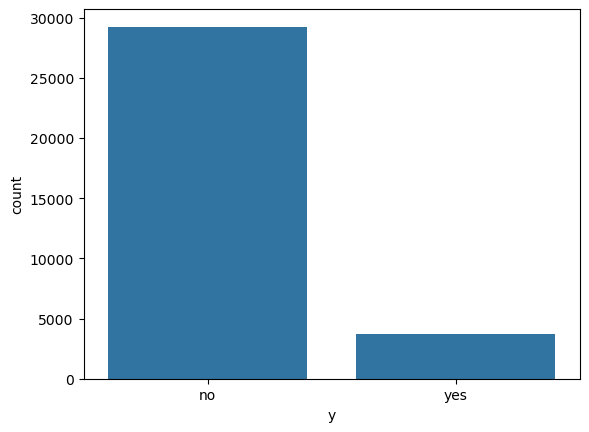

In [7]:
sns.countplot(df,x='y')

In [8]:
# percentage of data in the y
df['y'].value_counts()/len(df)*100

y
no     88.734446
yes    11.265554
Name: count, dtype: float64

# Univariate Analysis
## plotting the numerical and categorical variables

In [9]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [11]:
plt.style.use("ggplot")

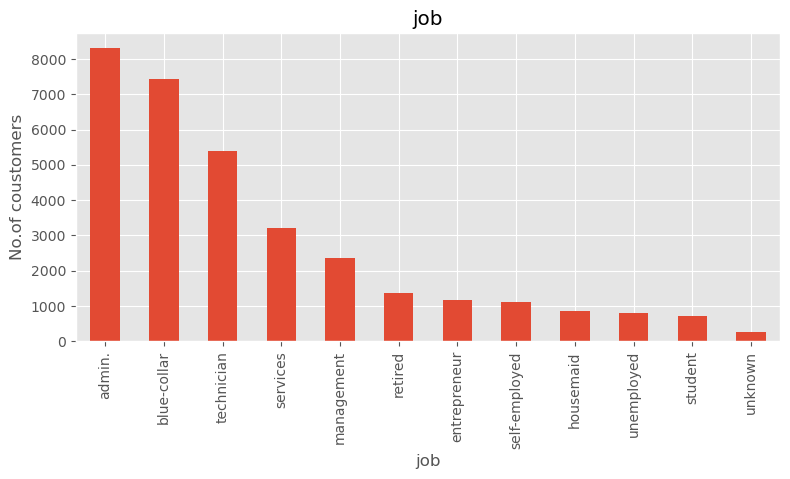

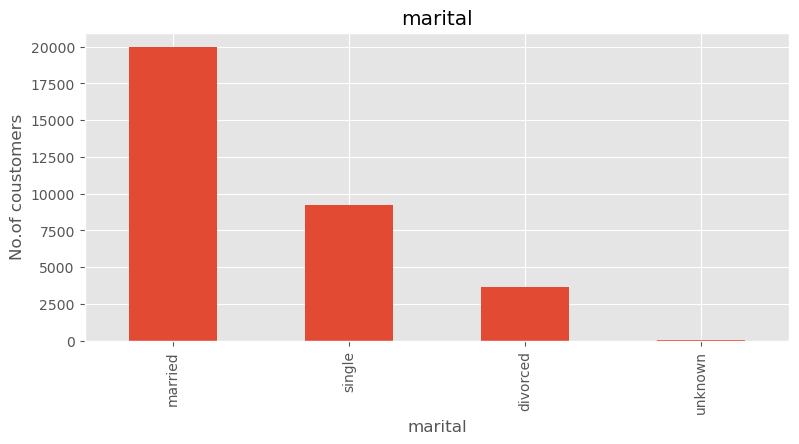

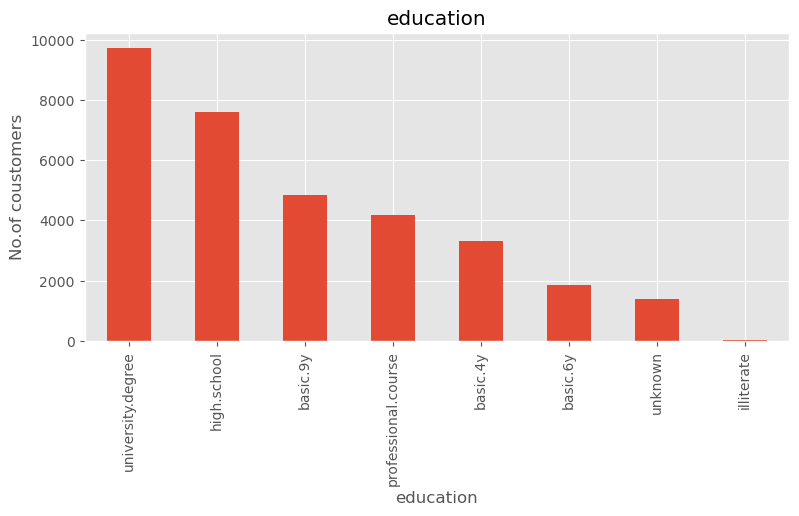

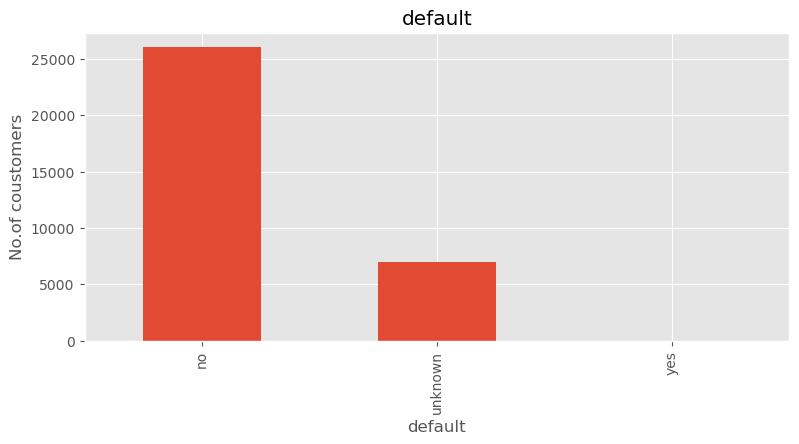

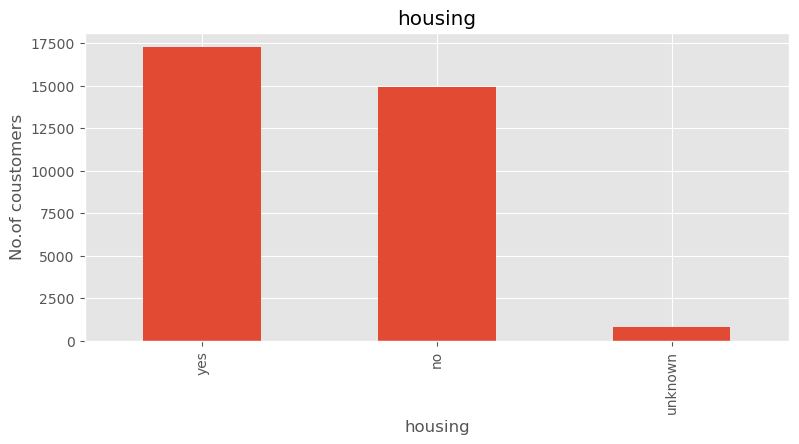

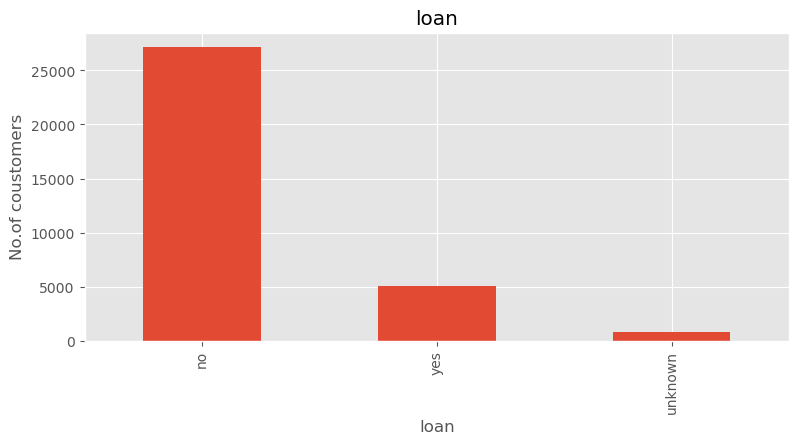

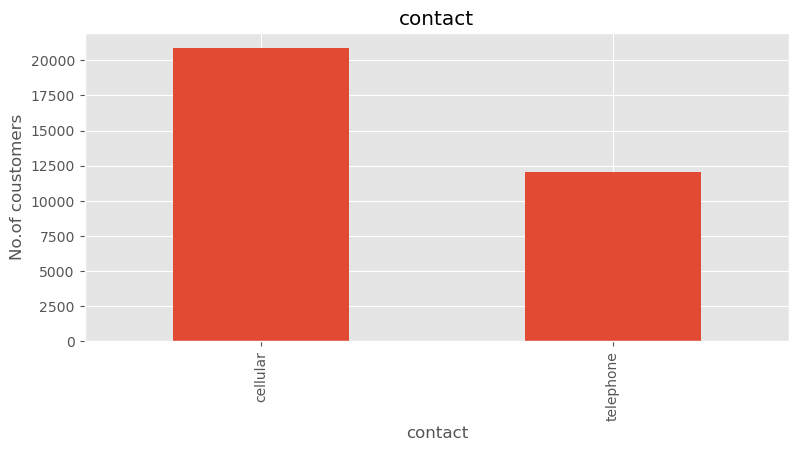

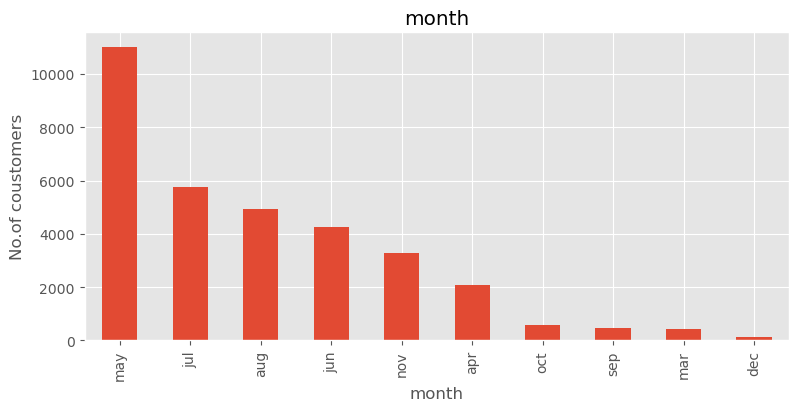

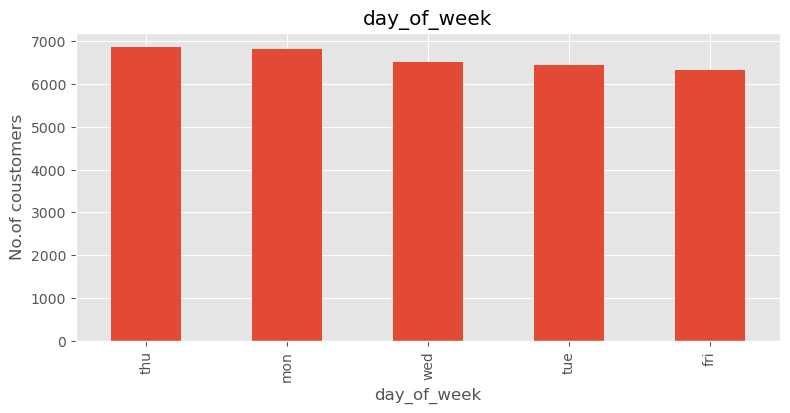

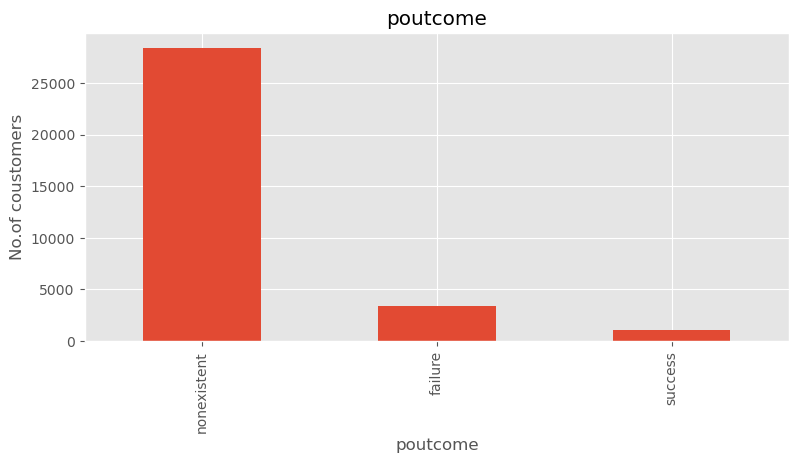

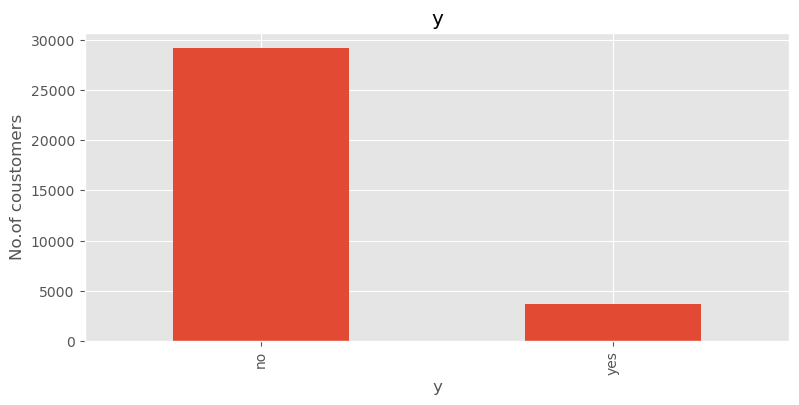

In [12]:
for column in categorical_cols:
    plt.figure(figsize=(20,4))
    plt.subplot(121)
    df[column].value_counts().plot(kind='bar')
    plt.xlabel(column)
    plt.ylabel('No.of coustomers')
    plt.title(column)

C:\Users\dell\AppData\Local\Temp\ipykernel_4220\2198840371.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column], kde=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_4220\2198840371.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column], kde=True)
C:\Users\dell\AppData\Local\Te

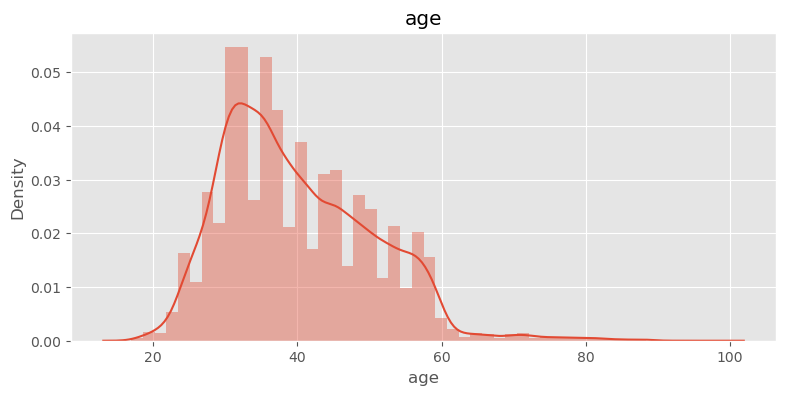

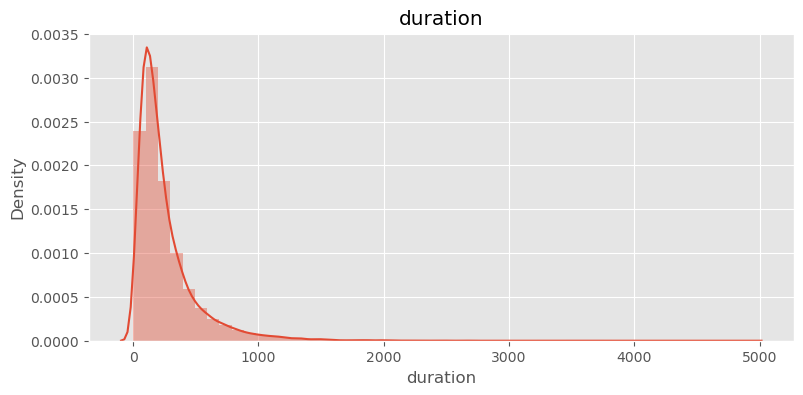

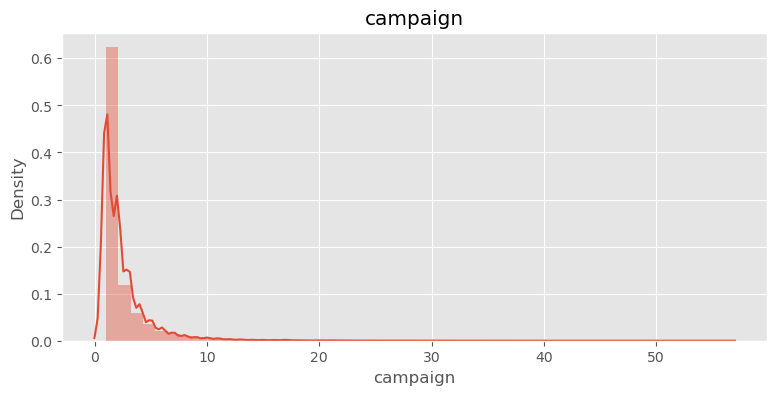

In [13]:
plt.style.use("ggplot")
for column in ["age", "duration", "campaign"]:
    plt.figure(figsize=(20,4))
    plt.subplot(121)
    sns.distplot(df[column], kde=True)
    plt.title(column)    

### Observations
- we can see there are too many outliers in these columns/ features
- we can handle them after filling with null values

In [14]:
df[numerical_cols].isnull().sum()

age         0
duration    0
campaign    0
pdays       0
previous    0
dtype: int64

In [15]:
df[categorical_cols].isnull().sum()

job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
poutcome       0
y              0
dtype: int64

- we can see that in the dataset having the Unknown value in the default column

In [16]:
for column in categorical_cols:
    mode = df[column].mode()[0]
    df[column] = df[column].replace('unknown',mode)

In [17]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,no,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


## Bivariate Analysis

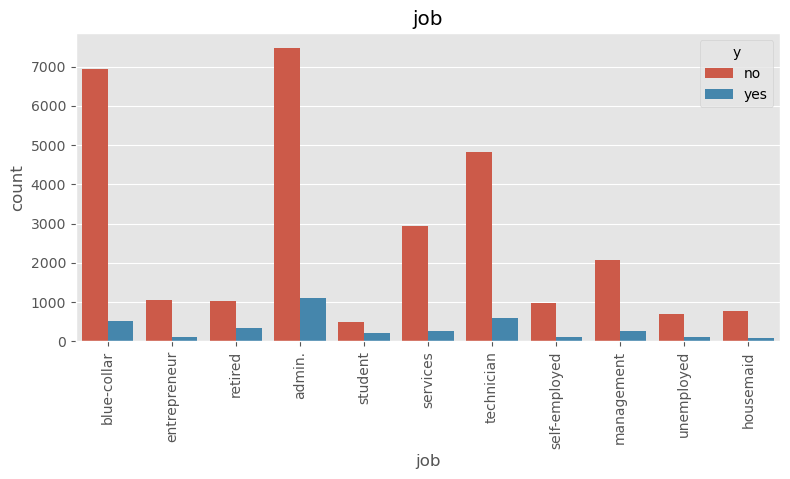

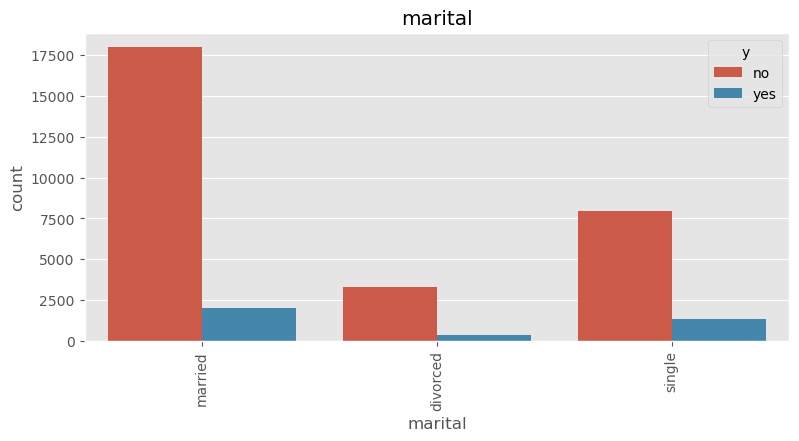

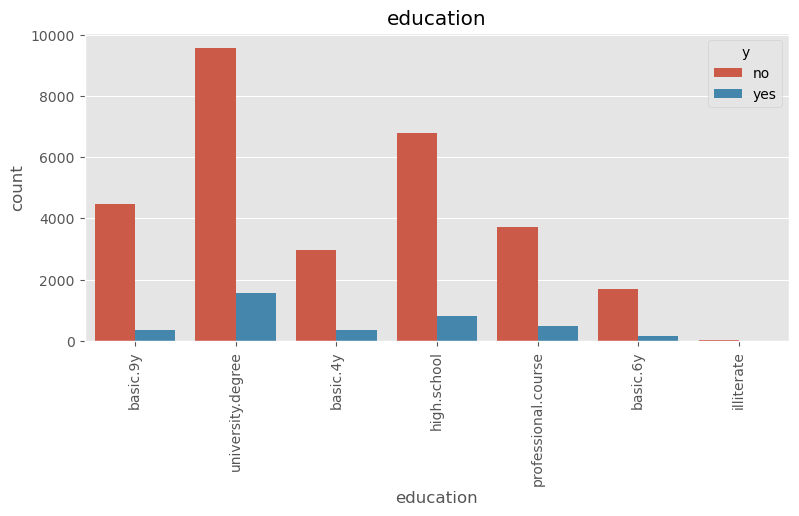

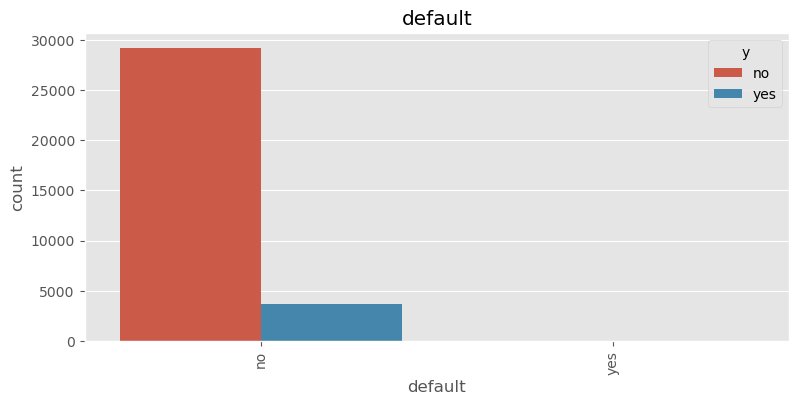

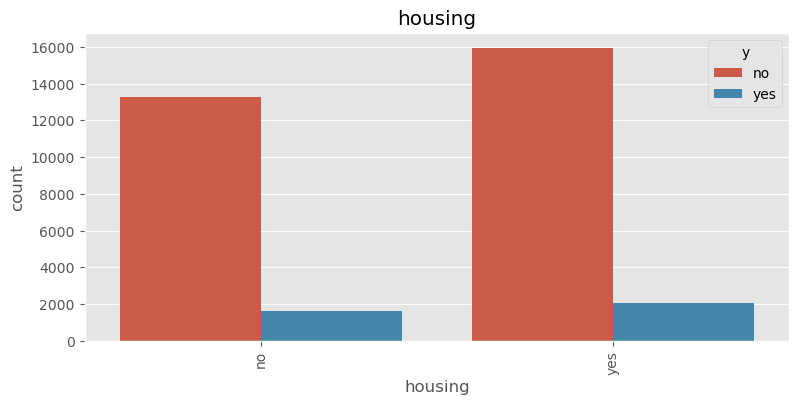

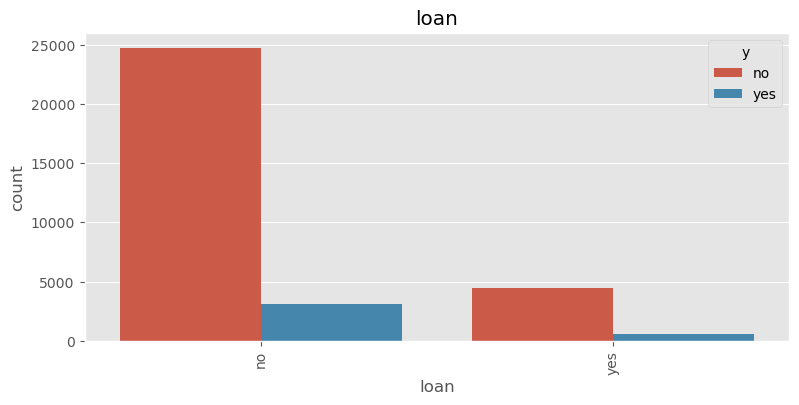

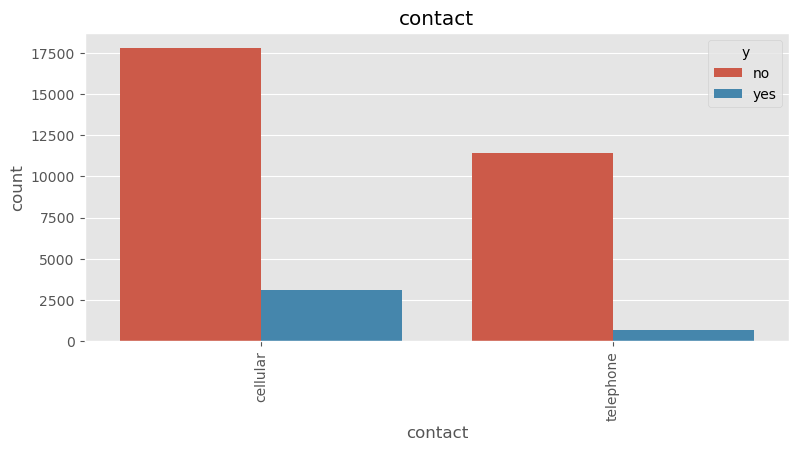

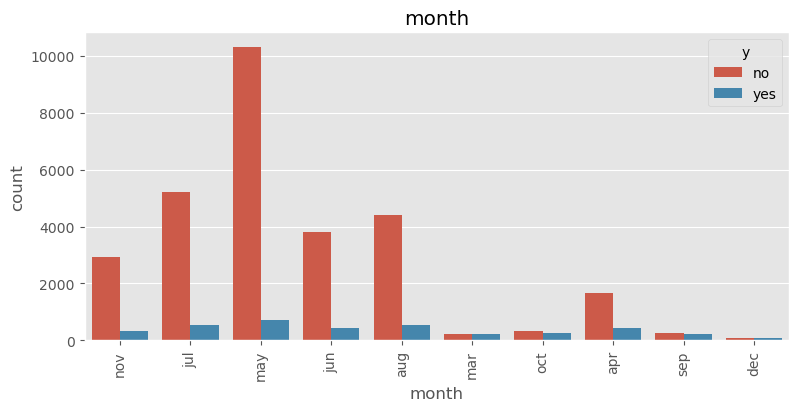

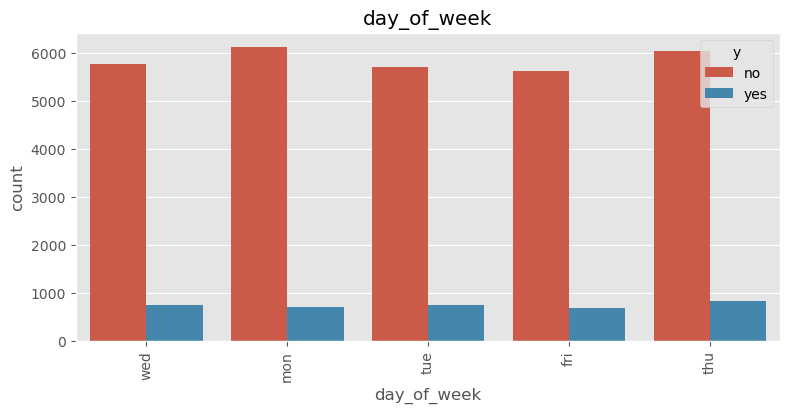

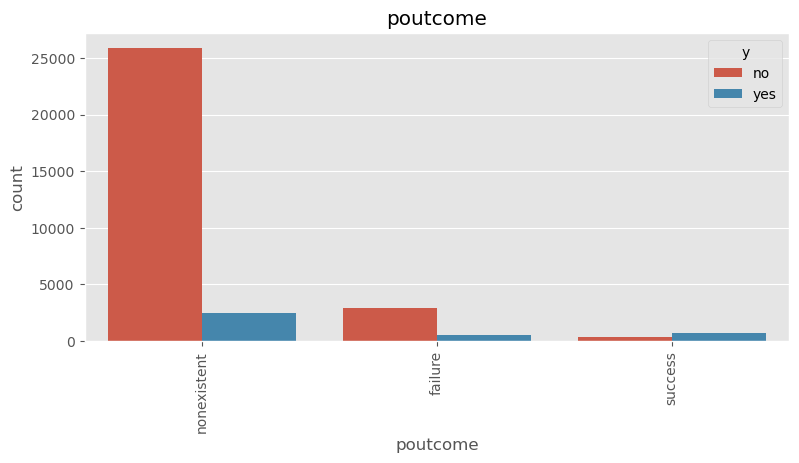

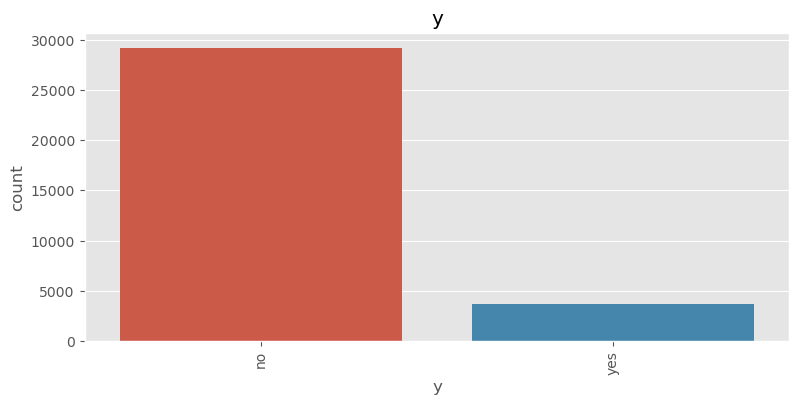

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(20,4))
    plt.subplot(121)
    sns.countplot(df,x=df[col],hue=df['y'])
    plt.title(col)
    plt.xticks(rotation=90)

In [19]:
df.describe()

,age,duration,campaign,pdays,previous
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607,962.052413,0.174719
std,10.403636,258.975917,2.752326,187.951096,0.499025
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


- Removing the Pdays and previous as their are not required.

In [20]:
df.drop(['pdays','previous'],axis=1,inplace=True)

In [21]:
df.describe()

,age,duration,campaign
count,32950.000000,32950.000000,32950.000000
mean,40.014112,258.127466,2.560607
std,10.403636,258.975917,2.752326
min,17.000000,0.000000,1.000000
25%,32.000000,103.000000,1.000000
50%,38.000000,180.000000,2.000000
75%,47.000000,319.000000,3.000000
max,98.000000,4918.000000,56.000000


### Handling the outliers for these colummns

In [22]:
lower_boundries=[]
upper_boundries=[]
for col in ['age','duration','campaign']:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5*IQR)
    upper_bound = Q3 + (1.5*IQR)
    print(col,':',lower_bound,col,':',upper_bound)
    lower_boundries.append(lower_bound)
    upper_boundries.append(upper_bound)

age : 9.5 age : 69.5
duration : -221.0 duration : 643.0
campaign : -2.0 campaign : 6.0


In [23]:
lower_boundries

[9.5, -221.0, -2.0]

In [24]:
upper_boundries

[69.5, 643.0, 6.0]

In [25]:
j = 0
for i in ["age", "duration", "campaign"]:
    df = df[(df[i] >= lower_boundries[j]) & (df[i] <= upper_boundries[j])]
    j += 1

In [26]:
df.describe()

,age,duration,campaign
count,28446.000000,28446.000000,28446.000000
mean,39.609822,207.044294,2.041131
std,9.690820,140.002342,1.279830
min,17.000000,0.000000,1.000000
25%,32.000000,102.000000,1.000000
50%,38.000000,171.000000,2.000000
75%,47.000000,281.000000,3.000000
max,69.000000,643.000000,6.000000


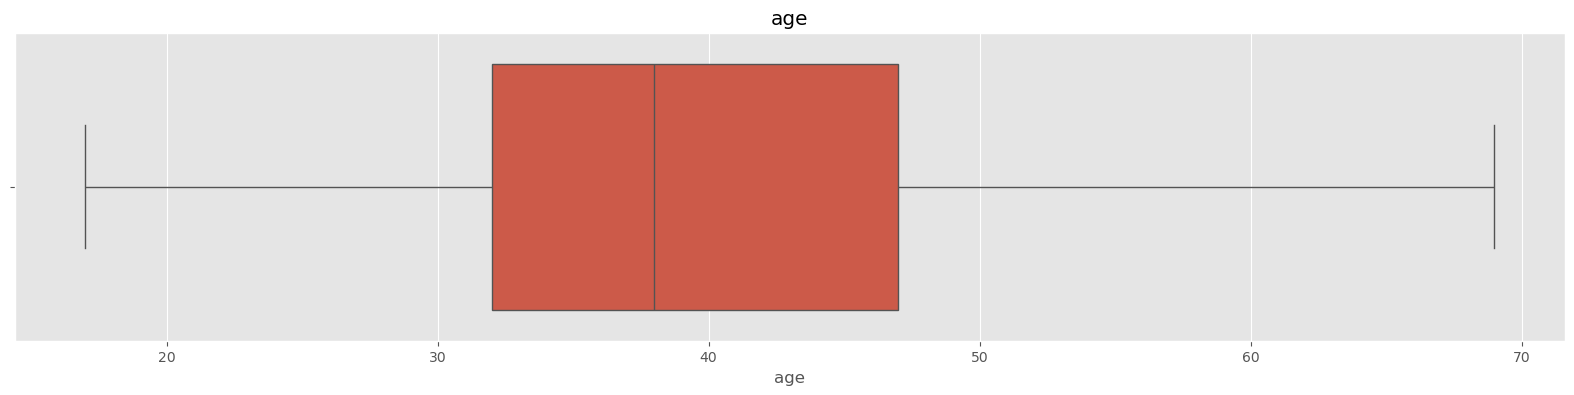

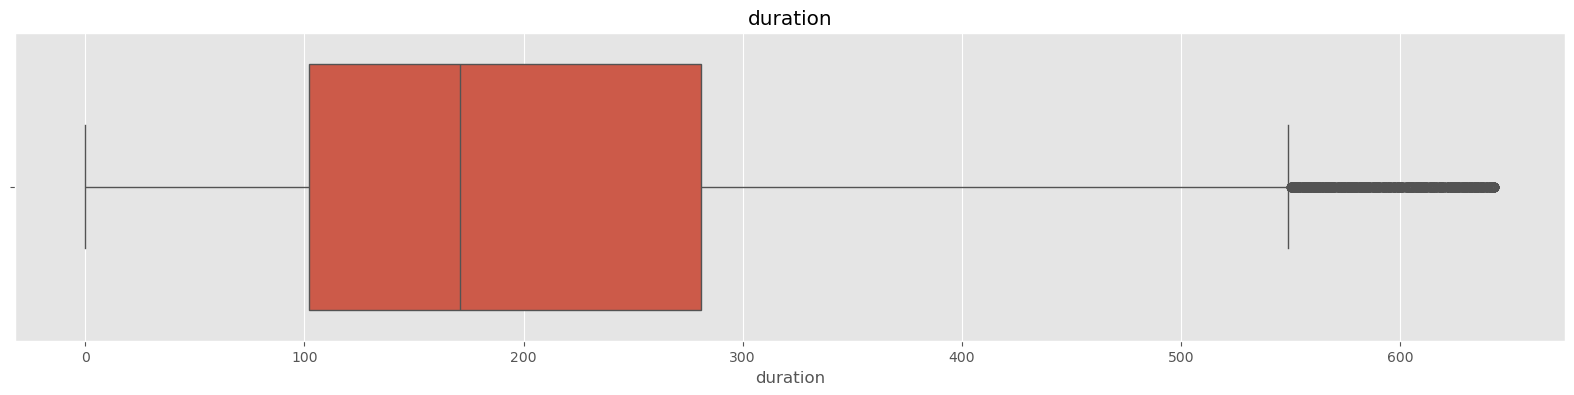

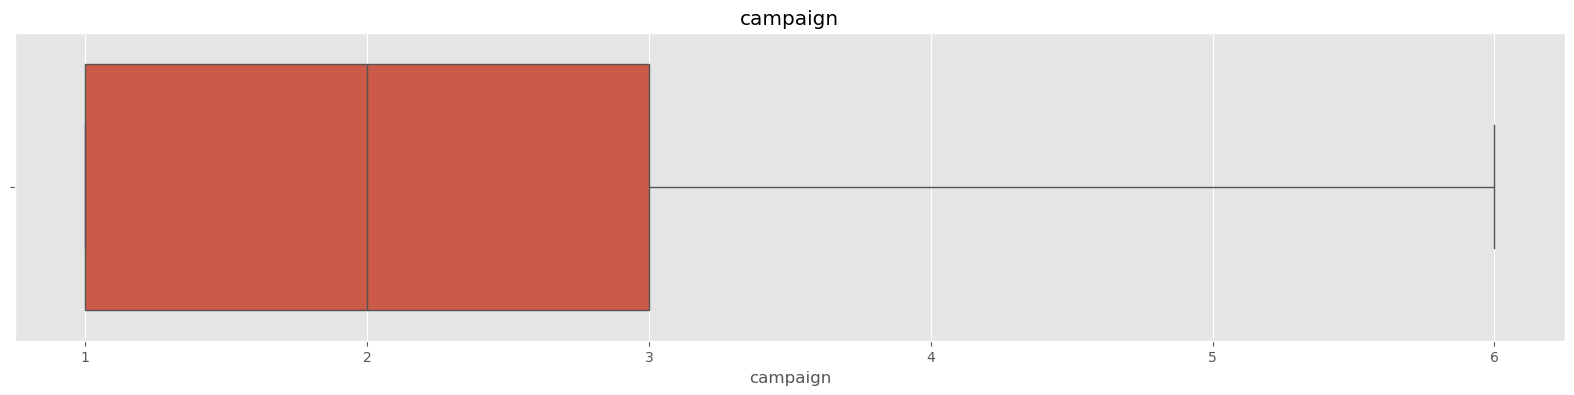

In [27]:
for i in ['age','duration','campaign']:
    plt.figure(figsize=(20,4))
    sns.boxplot(df,x=df[i])
    plt.xlabel(i)
    plt.title(i)
    plt.xticks()

## Scaling the numerical_cols

In [66]:
from sklearn.preprocessing import MinMaxScaler

In [70]:
numerical_cols= ['age', 'duration', 'campaign']

In [73]:
scaler = MinMaxScaler().fit(df[numerical_cols])

In [74]:
df[numerical_cols] = scaler.transform(df[numerical_cols])

In [75]:
df[numerical_cols] 

,age,duration,campaign
0,0.615385,0.353033,0.6
1,0.384615,0.314152,0.2
2,1.000000,1.000000,0.0
3,0.365385,0.186625,0.2
4,0.807692,0.572317,0.2
...,...,...,...
32945,0.211538,0.298600,0.0
32946,0.673077,0.099533,0.0
32947,0.711538,0.203733,0.6
32948,0.230769,0.256610,0.0


## Encoding the Categorical_cols

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
# initializing label encoder
le= LabelEncoder()

# iterating through each categorical feature and label encoding them
for feature in categorical_cols:
    df[feature]= le.fit_transform(df[feature])

In [30]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,poutcome,y
0,49,1,1,2,0,0,0,0,7,4,227,4,1,0
1,37,2,1,6,0,0,0,1,7,4,202,2,0,0
3,36,0,1,6,0,1,0,1,6,1,120,2,1,0
4,59,5,0,6,0,0,0,0,4,3,368,2,1,0
5,29,0,2,6,0,0,0,0,1,4,256,2,1,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28446 entries, 0 to 32949
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          28446 non-null  int64
 1   job          28446 non-null  int32
 2   marital      28446 non-null  int32
 3   education    28446 non-null  int32
 4   default      28446 non-null  int32
 5   housing      28446 non-null  int32
 6   loan         28446 non-null  int32
 7   contact      28446 non-null  int32
 8   month        28446 non-null  int32
 9   day_of_week  28446 non-null  int32
 10  duration     28446 non-null  int64
 11  campaign     28446 non-null  int64
 12  poutcome     28446 non-null  int32
 13  y            28446 non-null  int32
dtypes: int32(11), int64(3)
memory usage: 2.1 MB


## Separating the Independent and dependent variables

In [32]:
X = df.iloc[:,:-1]

In [33]:
y=df.iloc[:,-1]

In [34]:
X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,poutcome
0,49,1,1,2,0,0,0,0,7,4,227,4,1
1,37,2,1,6,0,0,0,1,7,4,202,2,0
3,36,0,1,6,0,1,0,1,6,1,120,2,1
4,59,5,0,6,0,0,0,0,4,3,368,2,1
5,29,0,2,6,0,0,0,0,1,4,256,2,1


In [35]:
y.head()

0    0
1    0
3    0
4    0
5    0
Name: y, dtype: int32

## checking the correlation

In [36]:
corr = df.corr()
corr

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,poutcome,y
age,1.000000,-0.032478,-0.396431,-0.110217,0.002886,-0.006031,-0.002199,0.034902,-0.032683,-0.024189,0.001821,0.012400,0.017650,-0.016685
job,-0.032478,1.000000,0.034407,0.137615,0.016424,0.007474,-0.014776,-0.029296,-0.028807,-0.000200,-0.010633,-0.007319,0.005115,0.027898
marital,-0.396431,0.034407,1.000000,0.107594,-0.002952,0.018238,0.006637,-0.062985,-0.005569,0.005443,0.006178,-0.007276,0.005899,0.068515
education,-0.110217,0.137615,0.107594,1.000000,0.003024,0.018083,0.008007,-0.113672,-0.085819,-0.016265,-0.019808,-0.003612,0.018361,0.086239
default,0.002886,0.016424,-0.002952,0.003024,1.000000,-0.004472,-0.004350,-0.007772,-0.005579,0.007341,-0.007608,-0.005680,-0.007212,-0.003060
housing,-0.006031,0.007474,0.018238,0.018083,-0.004472,1.000000,0.035485,-0.078334,-0.021090,0.001655,-0.012261,-0.006153,-0.015221,0.012162
loan,-0.002199,-0.014776,0.006637,0.008007,-0.004350,0.035485,1.000000,-0.014155,-0.008958,-0.013251,-0.005963,0.013999,-0.006066,-0.004614
contact,0.034902,-0.029296,-0.062985,-0.113672,-0.007772,-0.078334,-0.014155,1.000000,0.278604,-0.008645,-0.031470,0.042355,0.126677,-0.147023
month,-0.032683,-0.028807,-0.005569,-0.085819,-0.005579,-0.021090,-0.008958,0.278604,1.000000,0.031020,0.007486,-0.040097,-0.068497,-0.004281
day_of_week,-0.024189,-0.000200,0.005443,-0.016265,0.007341,0.001655,-0.013251,-0.008645,0.031020,1.000000,0.029406,-0.054744,0.013275,0.008890


<Axes: >

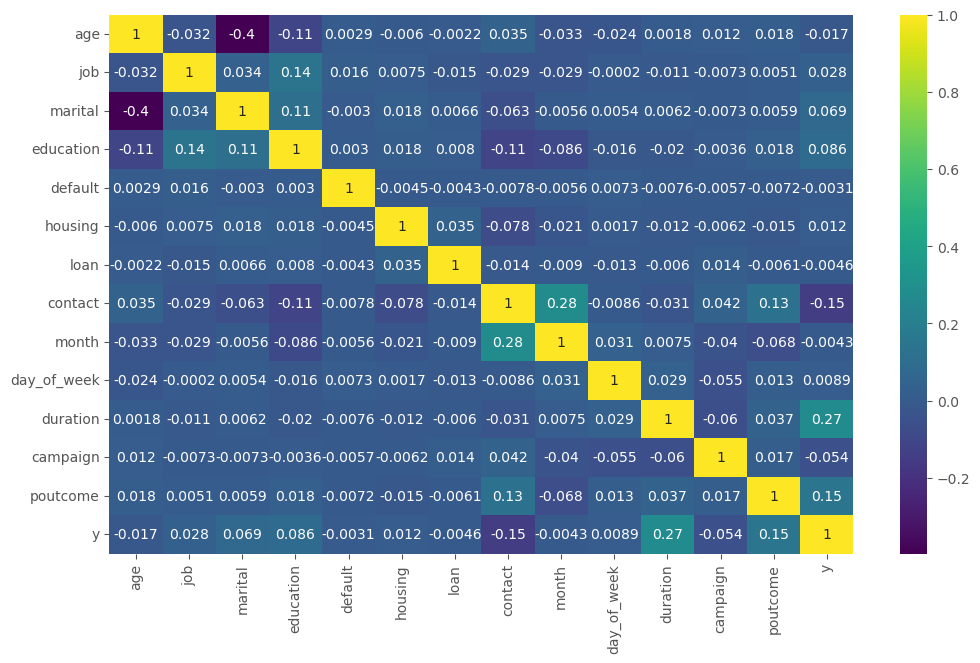

In [37]:
plt.figure(figsize=(12,7))
sns.heatmap(corr,cmap='viridis',annot=True)

### Handling the Imbalanced Dataset using `SMOTE`

In [38]:
!pip install -U imbalanced-learn scikit-learn

In [39]:
from imblearn.combine import SMOTETomek

# Correct initialization
smote = SMOTETomek(sampling_strategy=0.75, random_state=42)

In [40]:
x_sm, y_sm = smote.fit_resample(X, y)

In [41]:
y_sm.value_counts()

y
0    25967
1    19435
Name: count, dtype: int64

In [42]:
x_train, x_test, y_train, y_test= train_test_split(x_sm, y_sm, test_size=0.2, random_state=42)

<IPython.core.display.Javascript object>

In [43]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((36321, 13), (9081, 13), (36321,), (9081,))

## Model Training and Evalution

In [44]:
from sklearn.linear_model import LogisticRegression

In [46]:
model  = LogisticRegression(max_iter=1000, random_state=42).fit(x_train,y_train)

In [47]:
preds = model.predict(x_test)

In [48]:
preds

array([1, 0, 0, ..., 1, 1, 1])

In [ ]:
## Checking the loss value

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [55]:
accuracy_score(y_test,preds)

0.803325624931175

In [58]:
con_mat=confusion_matrix(y_test,preds)
con_mat

array([[4276,  888],
       [ 898, 3019]], dtype=int64)

In [53]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      5164
           1       0.77      0.77      0.77      3917

    accuracy                           0.80      9081
   macro avg       0.80      0.80      0.80      9081
weighted avg       0.80      0.80      0.80      9081



<Axes: >

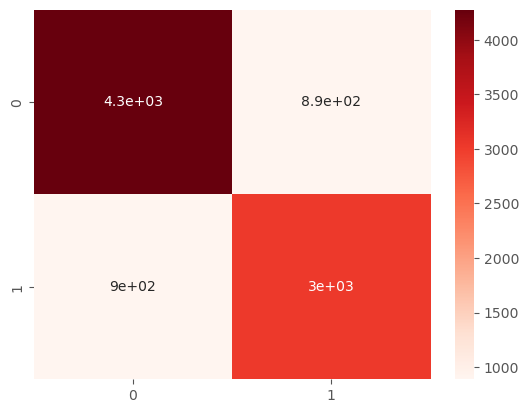

In [62]:
sns.heatmap(con_mat,cmap='Reds',annot=True)

## Trying other models

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [68]:
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 5️⃣ Fit models
dt_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)
xgb_model.fit(x_train, y_train)

# 6️⃣ Make predictions
y_pred_dt  = dt_model.predict(x_test)
y_pred_rf  = rf_model.predict(x_test)
y_pred_xgb = xgb_model.predict(x_test)

# 7️⃣ Evaluate models
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


<IPython.core.display.Javascript object>

C:\Users\dell\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:03:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Decision Tree Accuracy: 0.88800792864222
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      5164
           1       0.85      0.89      0.87      3917

    accuracy                           0.89      9081
   macro avg       0.88      0.89      0.89      9081
weighted avg       0.89      0.89      0.89      9081

[[4565  599]
 [ 418 3499]]
Random Forest Accuracy: 0.9317255808831626
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      5164
           1       0.91      0.93      0.92      3917

    accuracy                           0.93      9081
   macro avg       0.93      0.93      0.93      9081
weighted avg       0.93      0.93      0.93      9081

[[4802  362]
 [ 258 3659]]
XGBoost Accuracy: 0.9180706970597952
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5164
           1       0.90      0.91      0.91      3917

    acc